# Initialize Notebook

---

In [1]:
# Package imports
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing the classes and helper functions from the PRIZM files
from src.PRIZM_classes import ZeroShotModellerModule, PlottingModule

In [ ]:
# Initialize PRIZM
model_list = ['CARP','ESM1b','ESM1v','ESM2','Progen2','ProtGPT2','RITA','TranceptionNoRet','UniRep', #Sequence
              'eUniRep','EVE','GEMME','TranceptEVE','Tranception', 'MSATransformer', #MSA
              'ESM-IF1','MIF','MIFST','MULAN','ProteinMPNN','ProSST','ProtSSN','SaProt',#Structure
              'RSALOR','VenusREM', #all,
              ]
prizm = ZeroShotModellerModule('src/model_config.yaml') # Initialize the ZSM module
prizmplt = PlottingModule() # Initialize the plotting module

---

# Model Selection - Low-N Dataset

## Load dataset

---

In [ ]:
# Change the values of the following variables as needed
lowN_name = ['TOGT1_1_relact']
wt_threshold = [47.87383674]

In [ ]:
for name,wt_thresh in zip(lowN_name, wt_threshold):
    prizm.set_threshold(name,wt_thresh)
    prizm.load_scores(name,model_list)

---

## Process dataset

---

In [6]:
# Change the values of the following variables as needed
n_bootstrap = 1000 # Decrease to reduce computation time

In [ ]:
for name in lowN_name:
    prizm.compute_metrics(name,n_bootstrap=n_bootstrap, metrics = ['spearmanr','average_precision'])
    prizm.process_models(name)

In [ ]:
for name in lowN_name:
    print(f'Results for {name}')
    best_models = [prizm.best_models[name][cat] for cat in ['overall','sequence','MSA','structure']]
    worst_models = [prizm.worst_models[name][cat] for cat in ['overall','sequence','MSA','structure']]
    print('Best Overall Model:',best_models[0])
    print('Best Sequence Model:',best_models[1])
    print('Best MSA Model:',best_models[2])
    print('Best Structure Model:',best_models[3])
    print('---------------------------------')
    print('Worst Overall Model:',worst_models[0])
    print('Worst Sequence Model:',worst_models[1])
    print('Worst MSA Model:',worst_models[2])
    print('Worst Structure Model:',worst_models[3])
    print('---------------------------------')
    

Results for TOGT1_1_relact
Best Overall Model: VenusREM_4096
Best Sequence Model: ESM2_650M
Best MSA Model: Tranception_L
Best Structure Model: ProSST_1024
---------------------------------
Worst Overall Model: ProtGPT2
Worst Sequence Model: ProtGPT2
Worst MSA Model: GEMME
Worst Structure Model: ProtSSN
---------------------------------
Results for TOGT1_1_relact_clean
Best Overall Model: ESM2_150M
Best Sequence Model: ESM2_150M
Best MSA Model: GEMME
Best Structure Model: ProSST_128
---------------------------------
Worst Overall Model: MSATransformer
Worst Sequence Model: ESM1v
Worst MSA Model: MSATransformer
Worst Structure Model: MULAN_small
---------------------------------


In [ ]:
correct_sign = []
wrong_sign = []
df_ = prizm.metric_results['TOGT1_1_relact_clean']
df_ = df_.iloc[:,df_.columns.get_level_values('stat') == 'reverse']['spearmanr']
for model in df_.index:
    if not df_.loc[model].reverse and model != 'EVE':
        correct_sign.append(model)
    elif not df_.loc[model].reverse and model == 'EVE':
        wrong_sign.append(model)
    elif df_.loc[model].reverse and model != 'EVE':
        wrong_sign.append(model)
    else:
        correct_sign.append(model)

---

## Plot results

---

Plotting results for TOGT1_1_relact


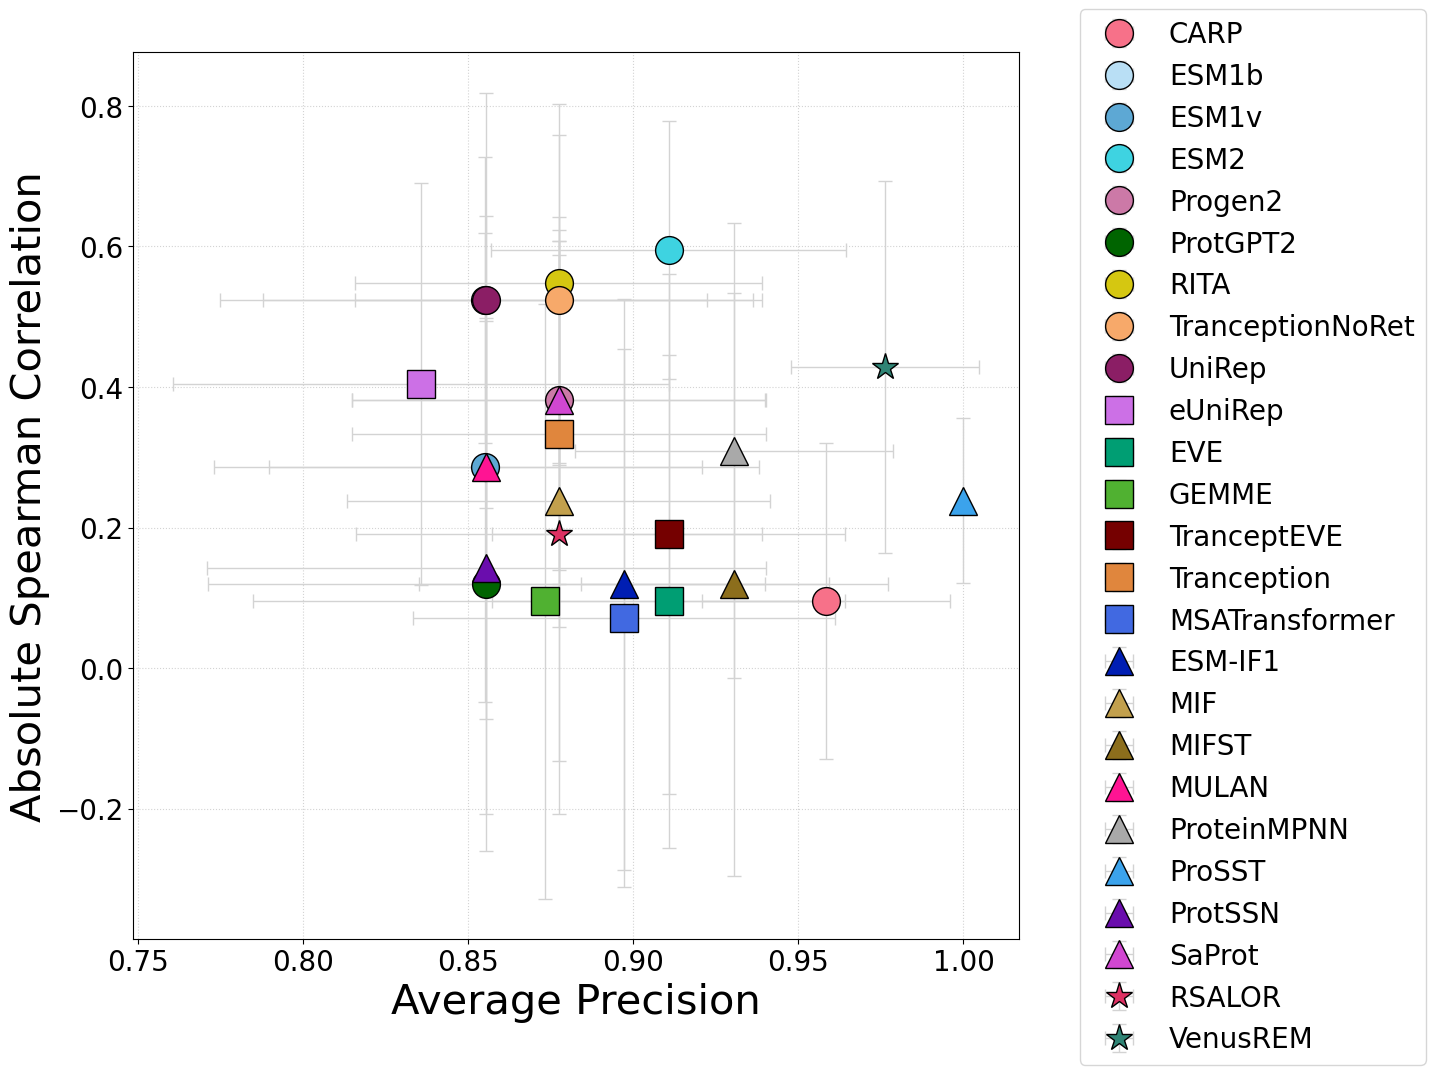

Plotting results for TOGT1_1_relact correct models


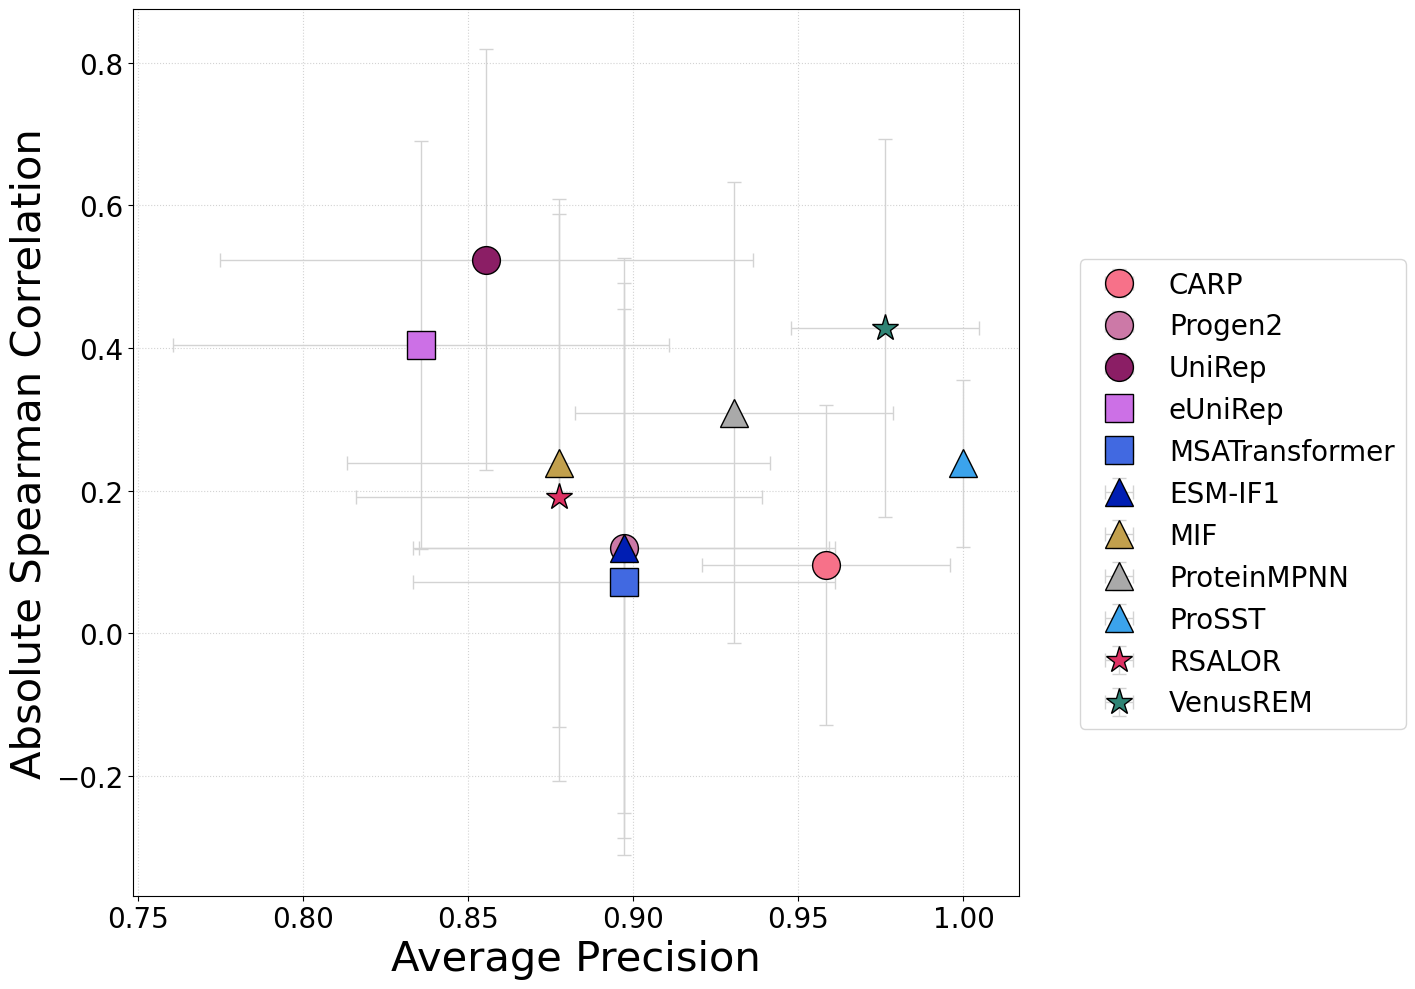

Plotting results for TOGT1_1_relact_clean


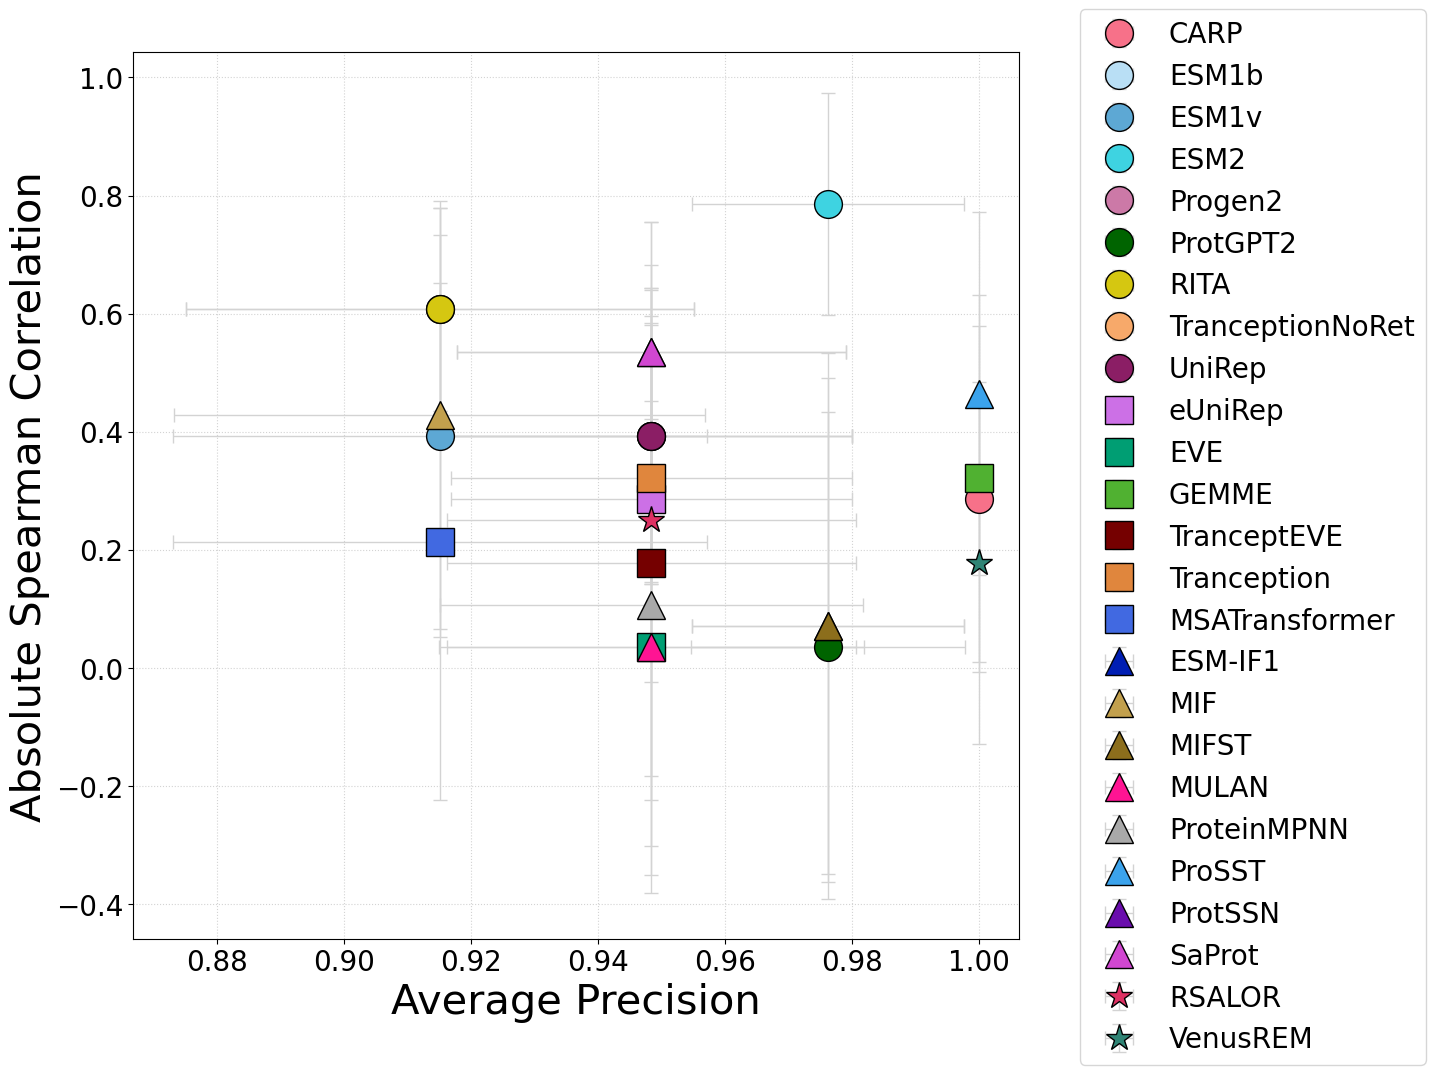

Plotting results for TOGT1_1_relact_clean correct models


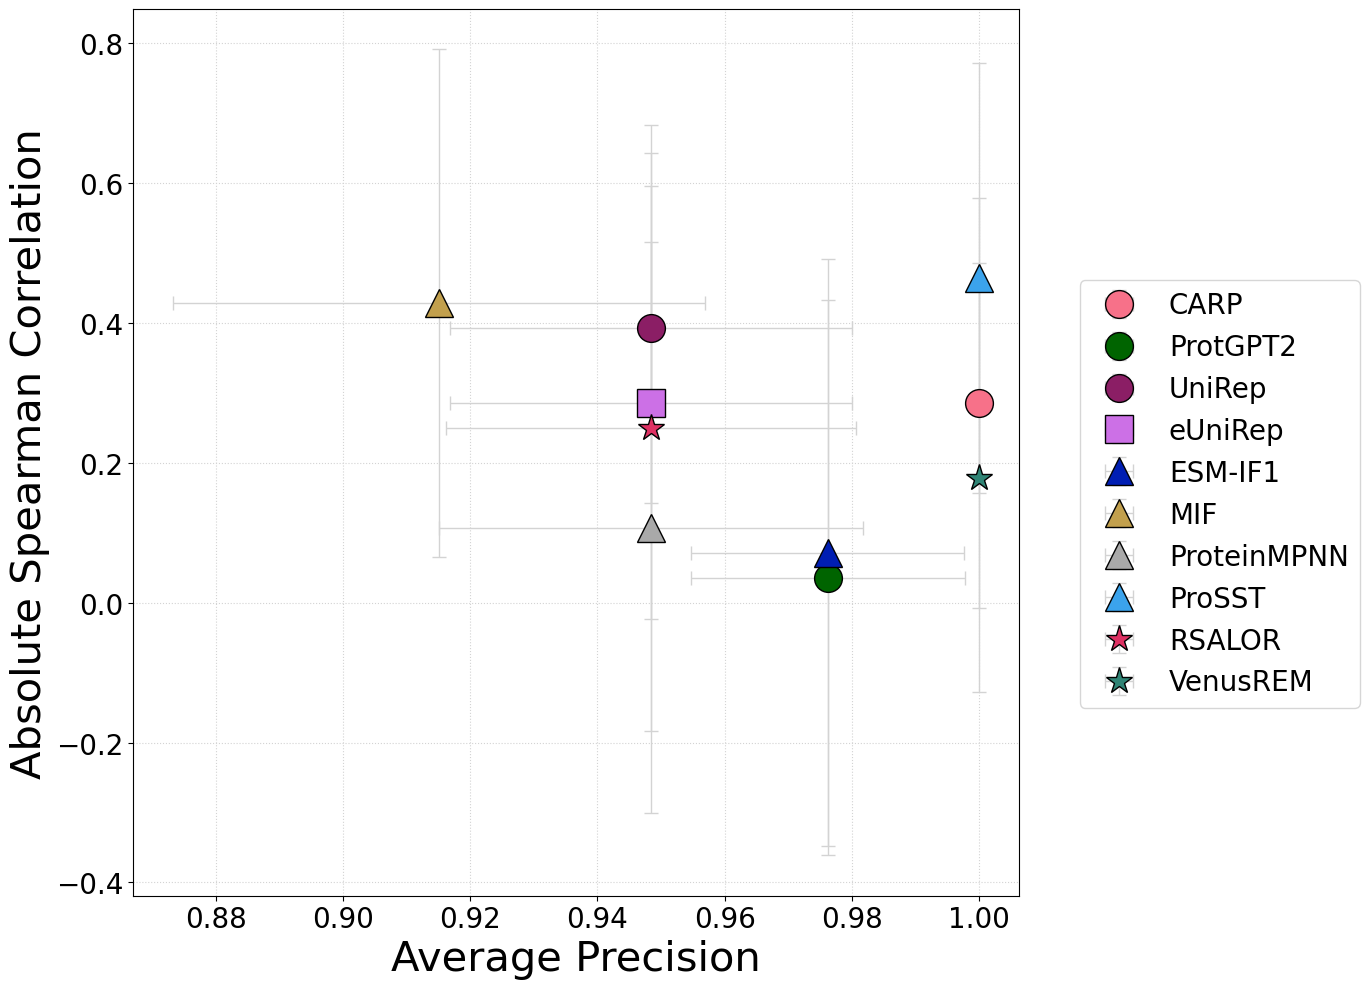

In [ ]:
# Plotting the model performances
for name in lowN_name:
    print(f'Plotting results for {name}')
    prizmplt.metrics(prizm, name, figsize=(14, 10))

    print(f'Plotting results for {name} correct models')
    prizmplt.metrics(prizm, name, figsize=(14, 10), use_correct=True)

Plotting results for TOGT1_1_relact


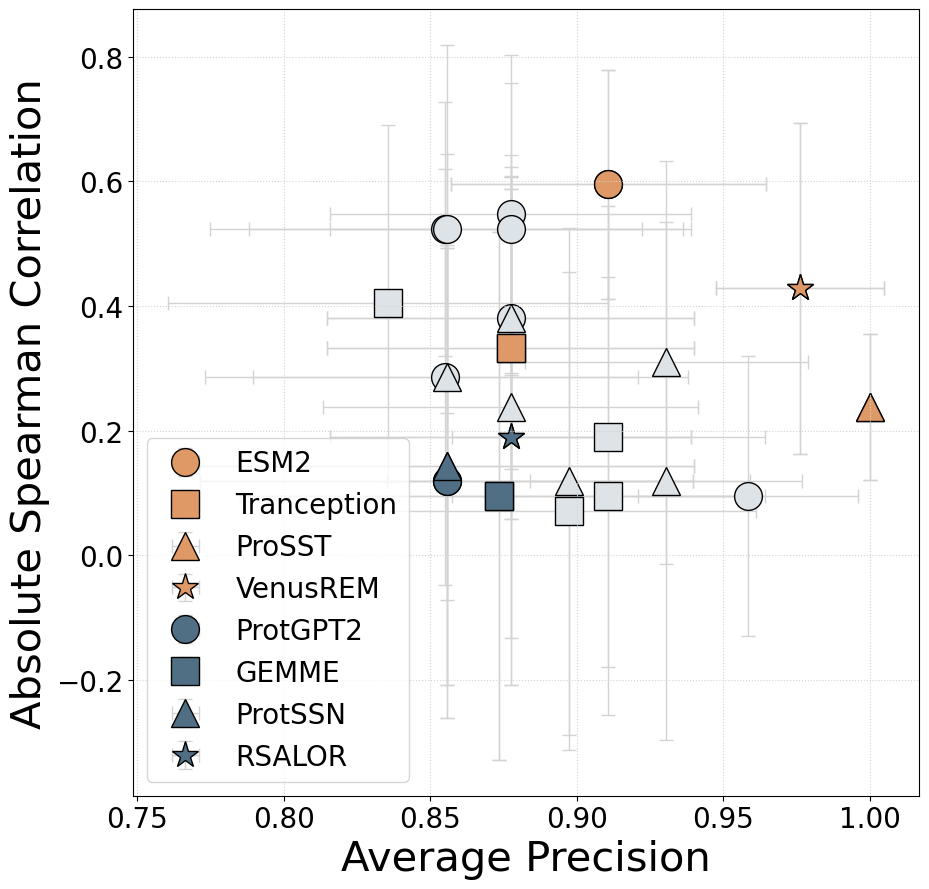

Plotting results for TOGT1_1_relact correct models


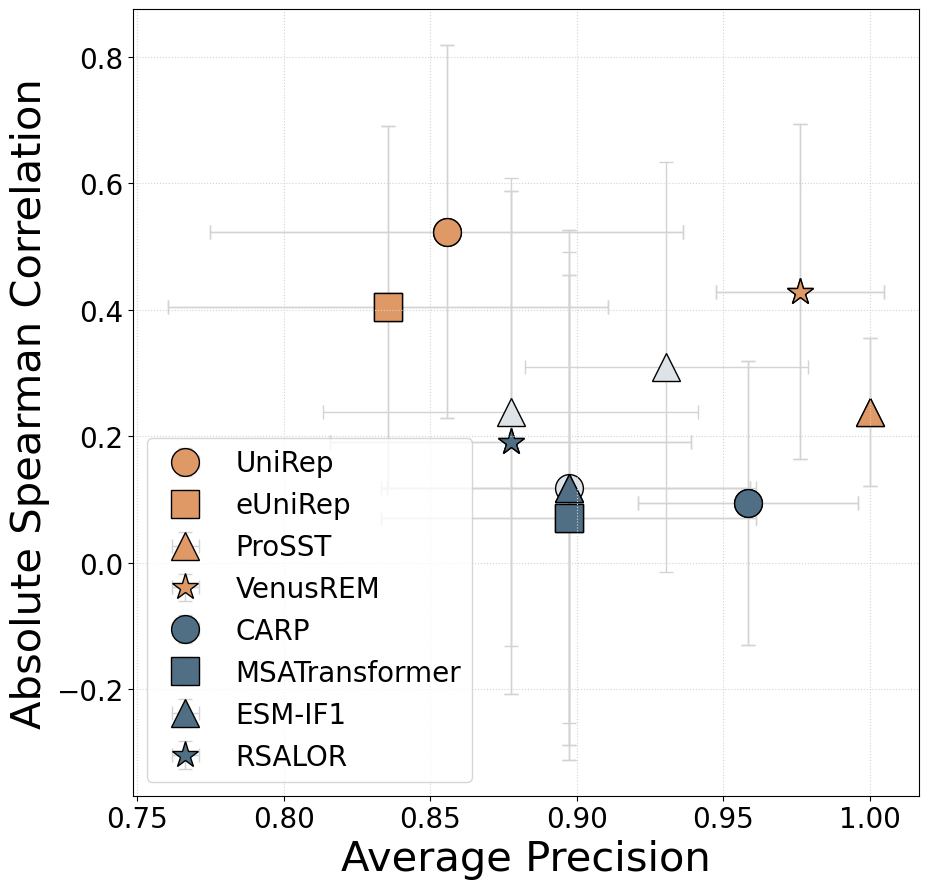

Plotting results for TOGT1_1_relact_clean


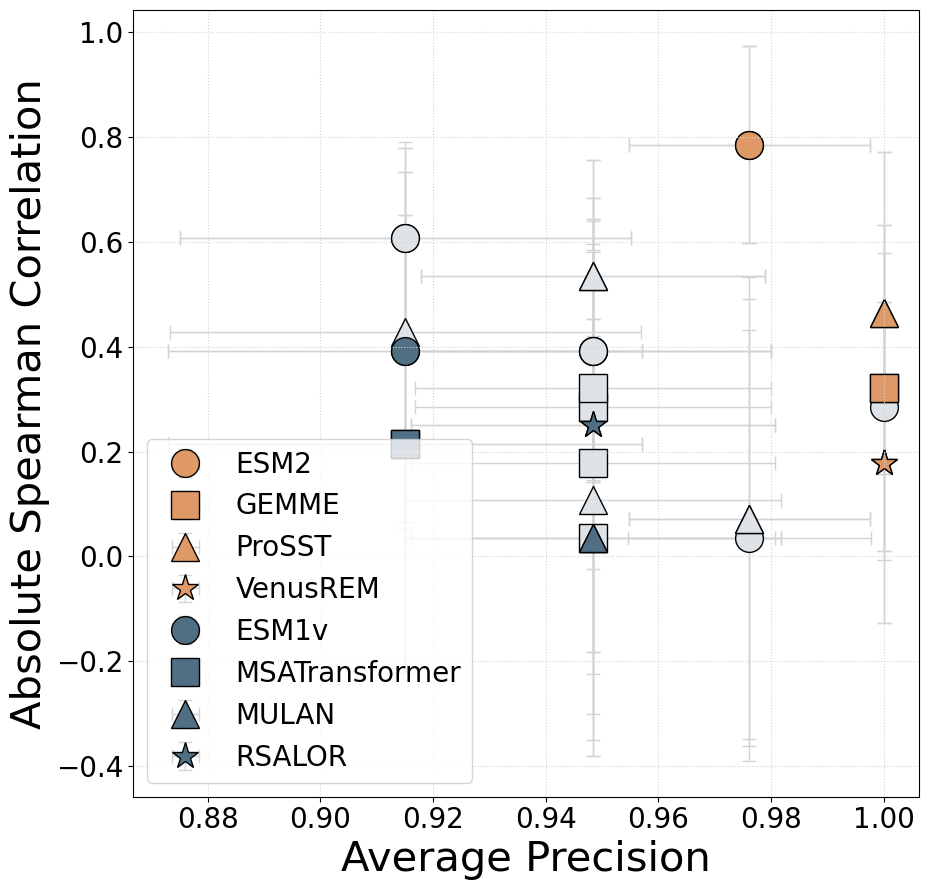

Plotting results for TOGT1_1_relact_clean correct models


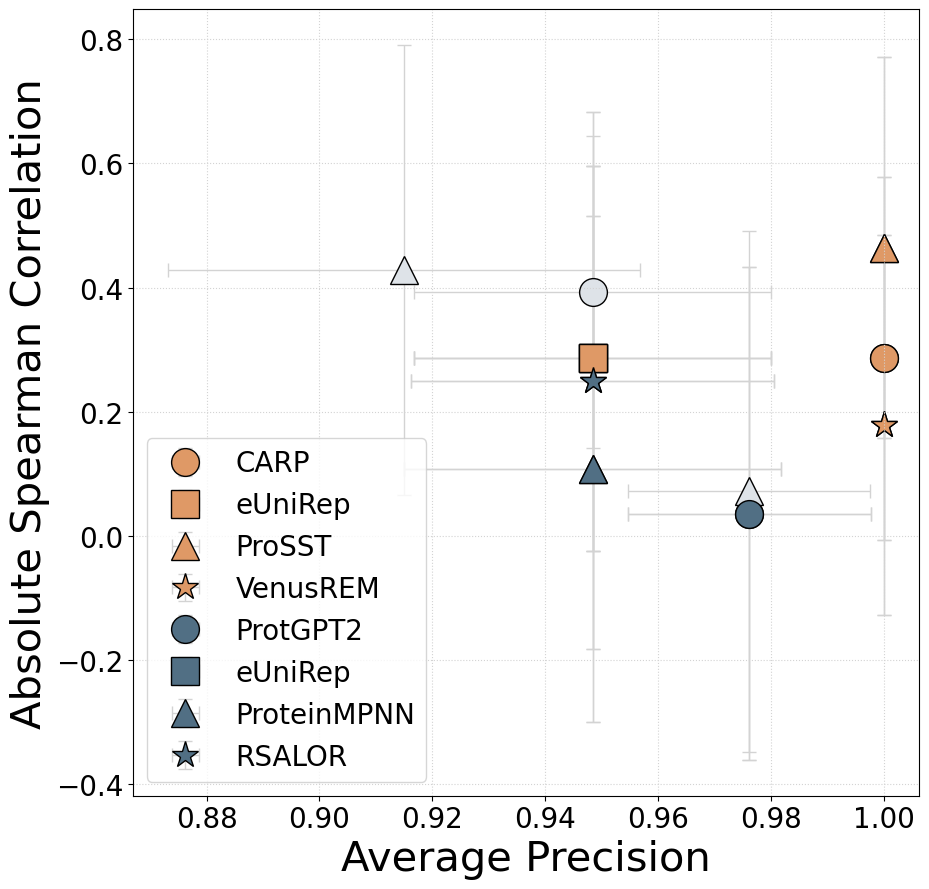

In [ ]:
# Plotting the model performances, with the best and worst models highlighted
for name in lowN_name:
    print(f'Plotting results for {name}')
    prizmplt.metrics_cat(prizm, name, figsize=(12, 9), legend_fontsize=20)

    print(f'Plotting results for {name} correct models')
    prizmplt.metrics_cat(prizm, name, figsize=(12, 9), use_correct=True, legend_fontsize=20)

Plotting results for TOGT1_1_relact
Overall Model
Best Overall Model: VenusREM_4096


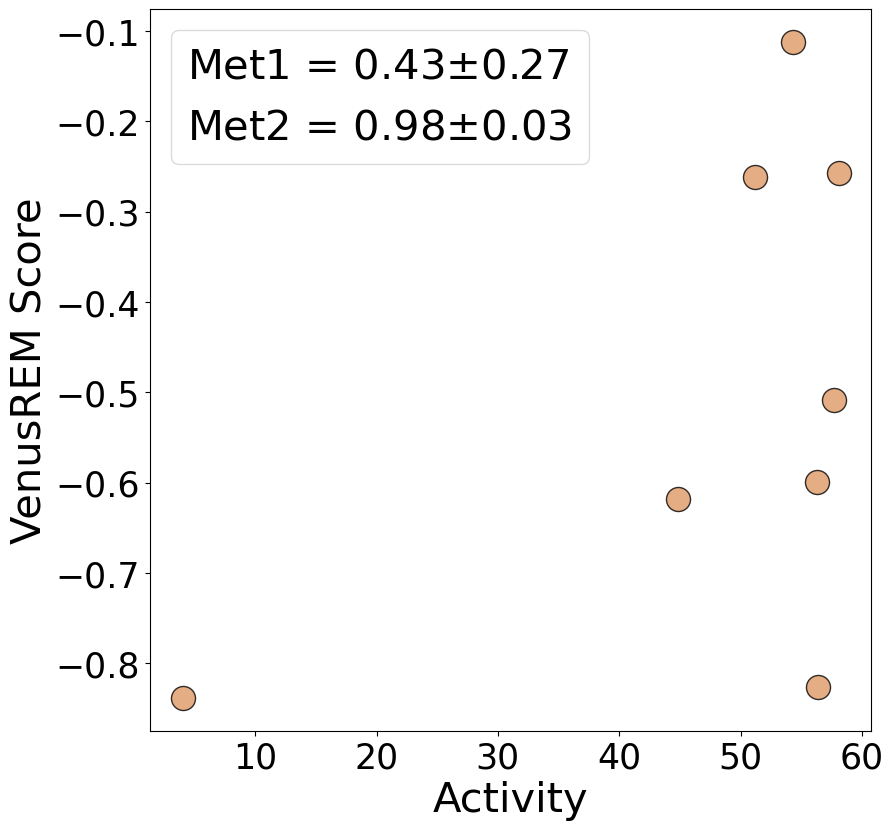

Worst Overall Model: ProtGPT2


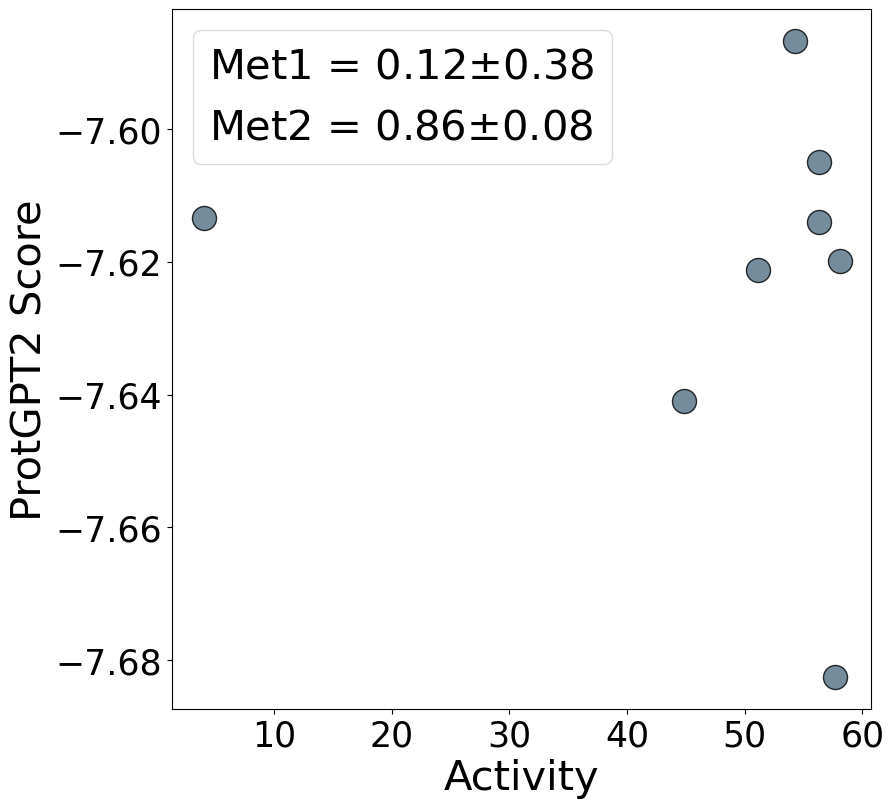

Sequence Model
Best Sequence Model: ESM2_650M


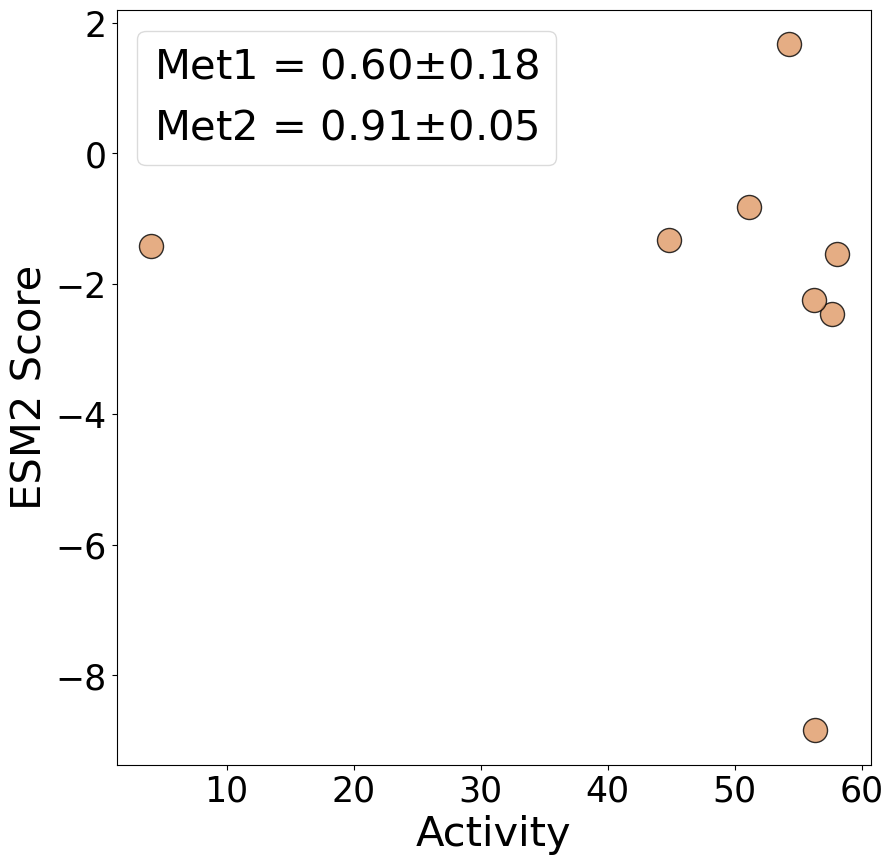

Worst Sequence Model: ProtGPT2


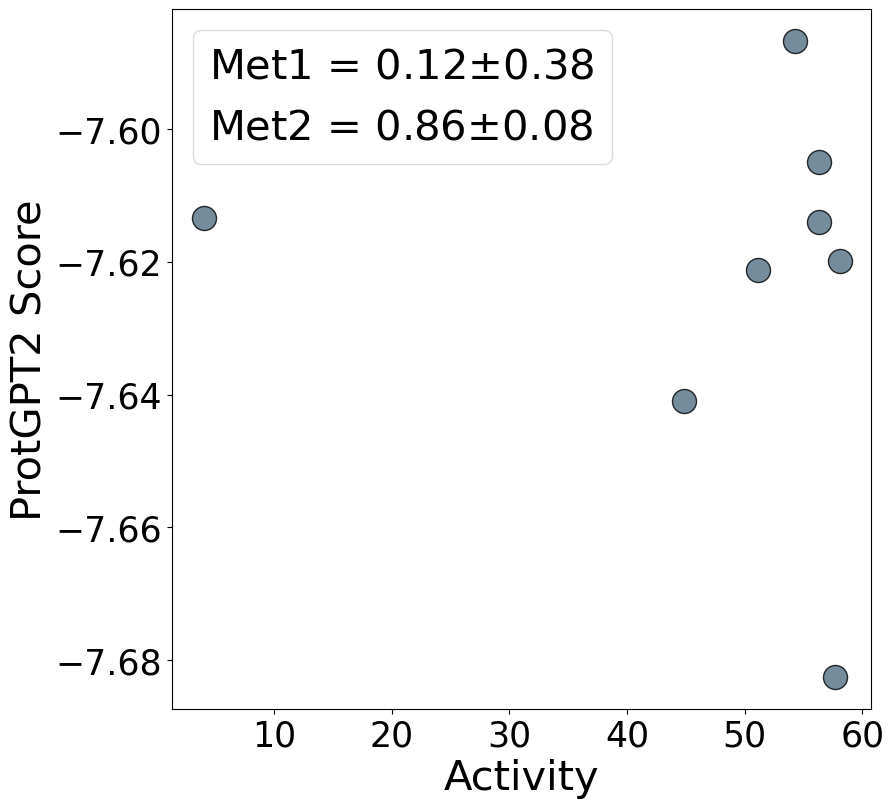

MSA Model
Best MSA Model: TranceptEVE_S


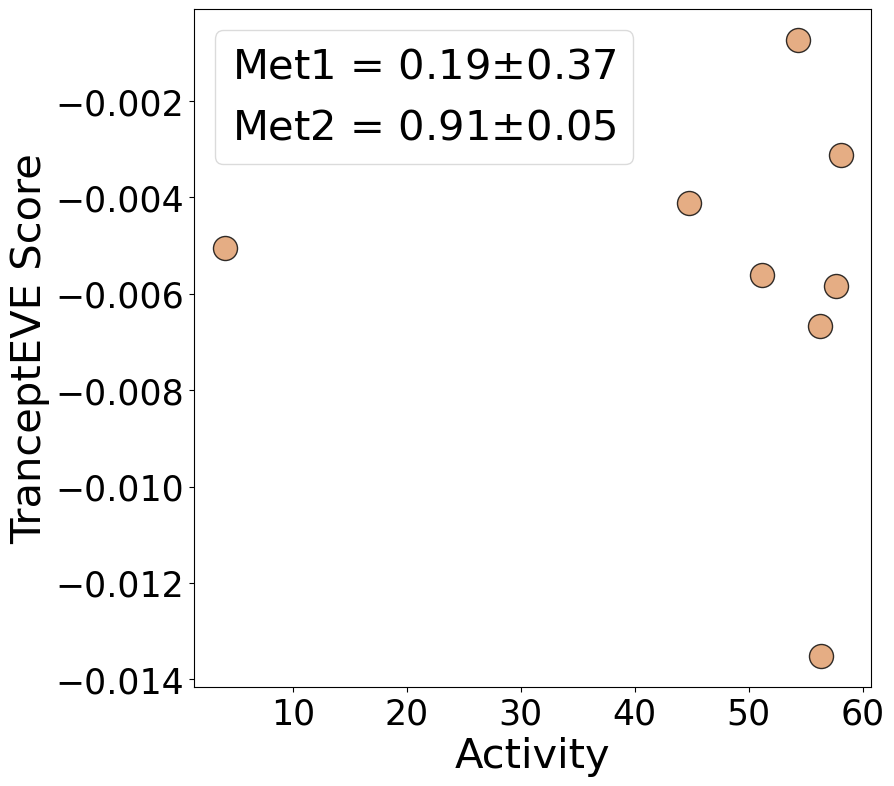

Worst MSA Model: GEMME


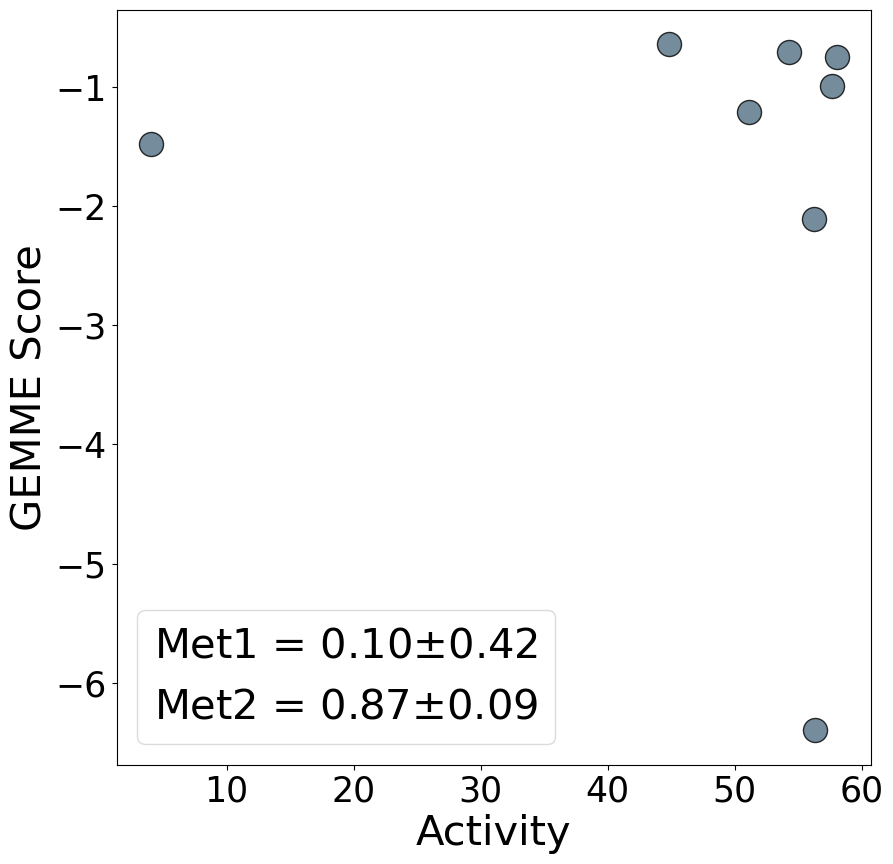

Structure Model
Best Structure Model: ProSST_1024


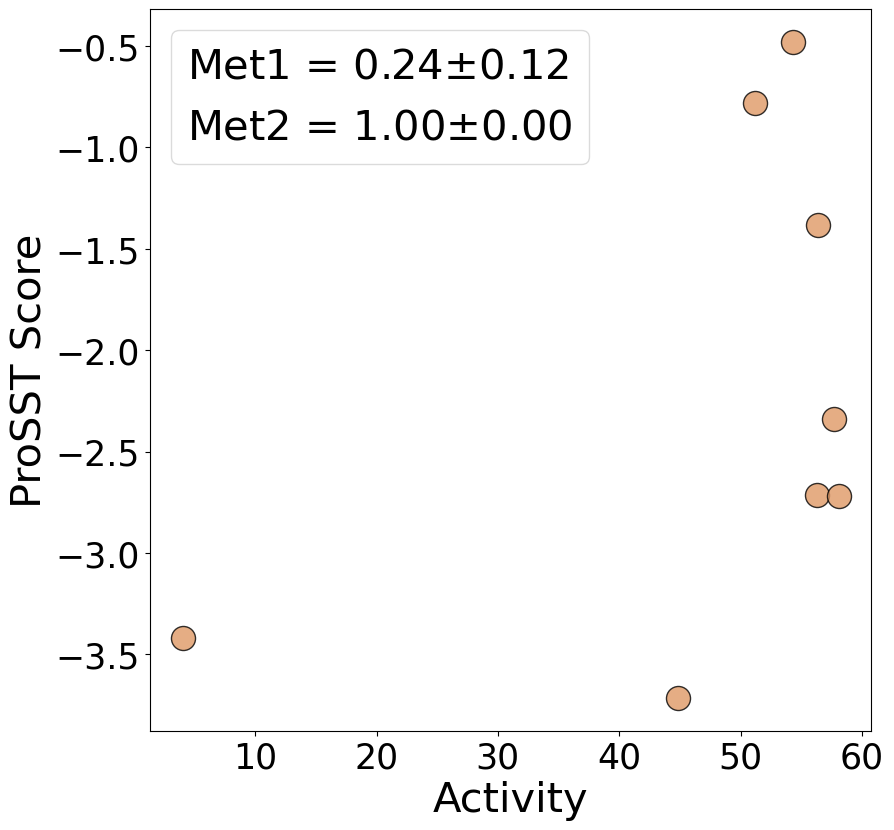

Worst Structure Model: ProtSSN


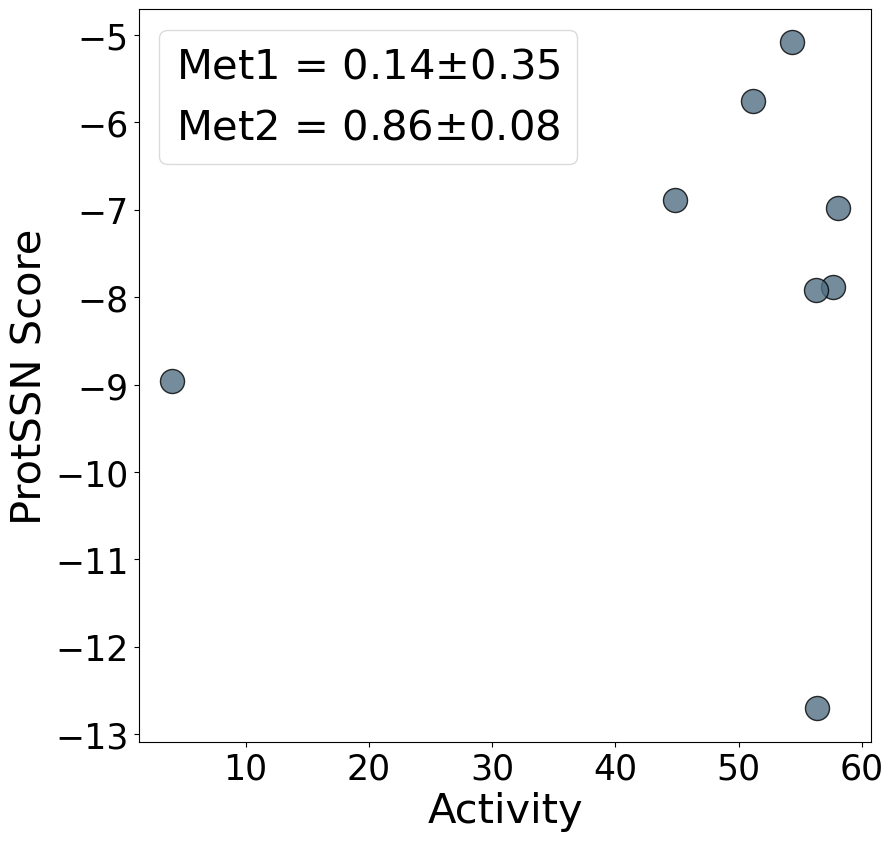

All features
Best Model using all features: VenusREM_4096


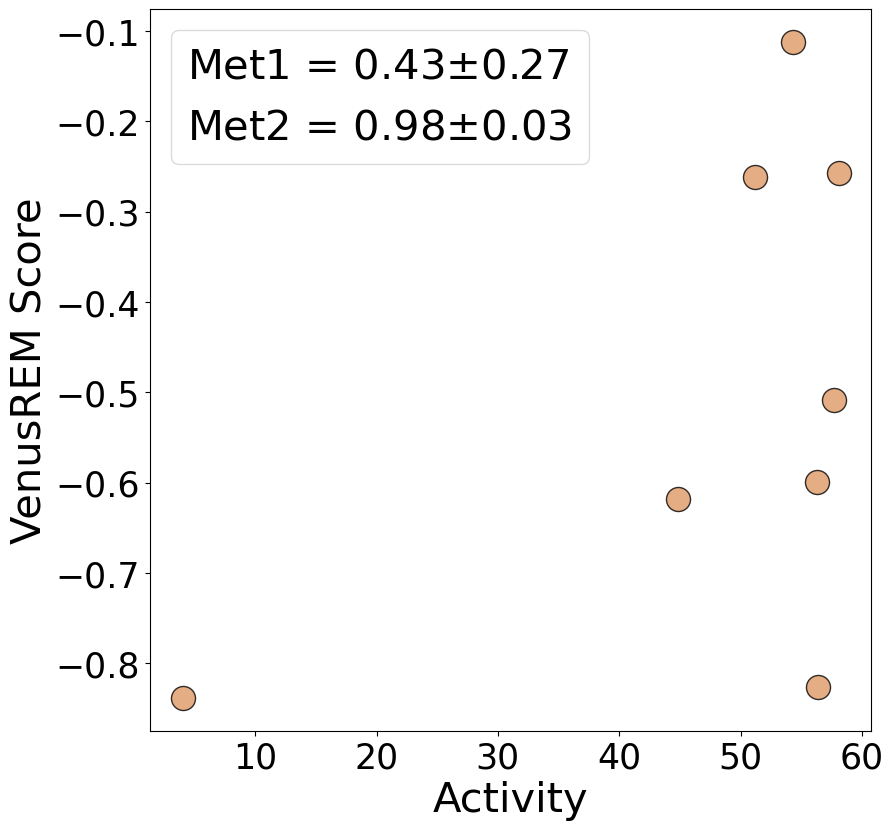

Worst Model using all features: RSALOR


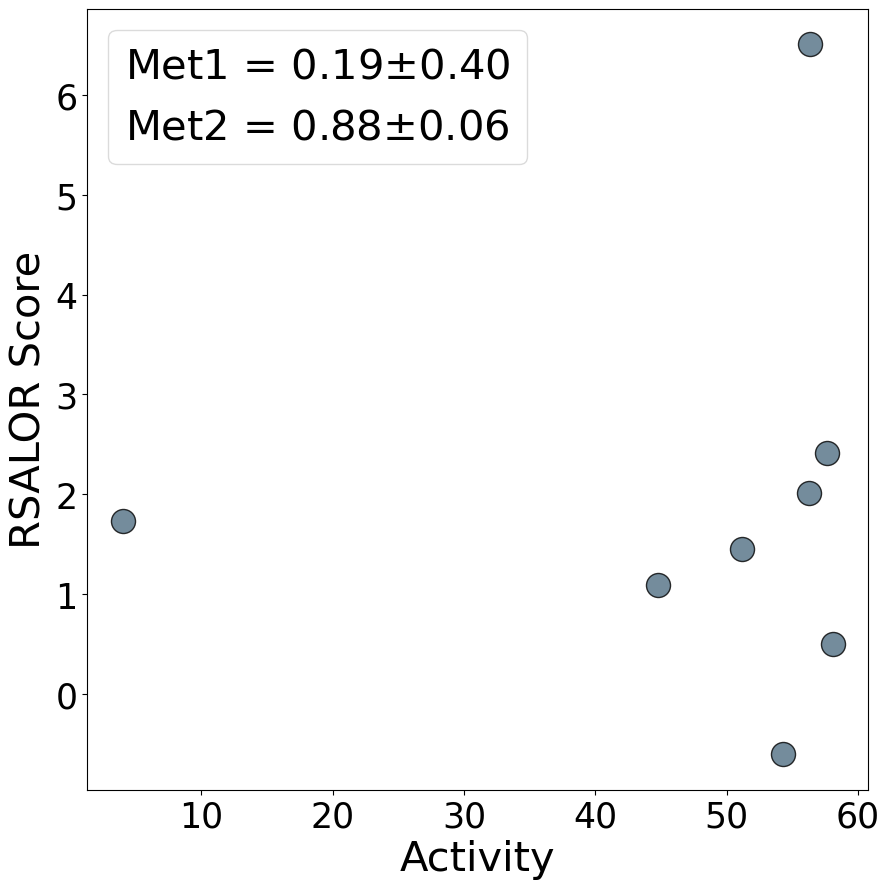

Plotting results for TOGT1_1_relact_clean
Overall Model
Best Overall Model: ESM2_150M


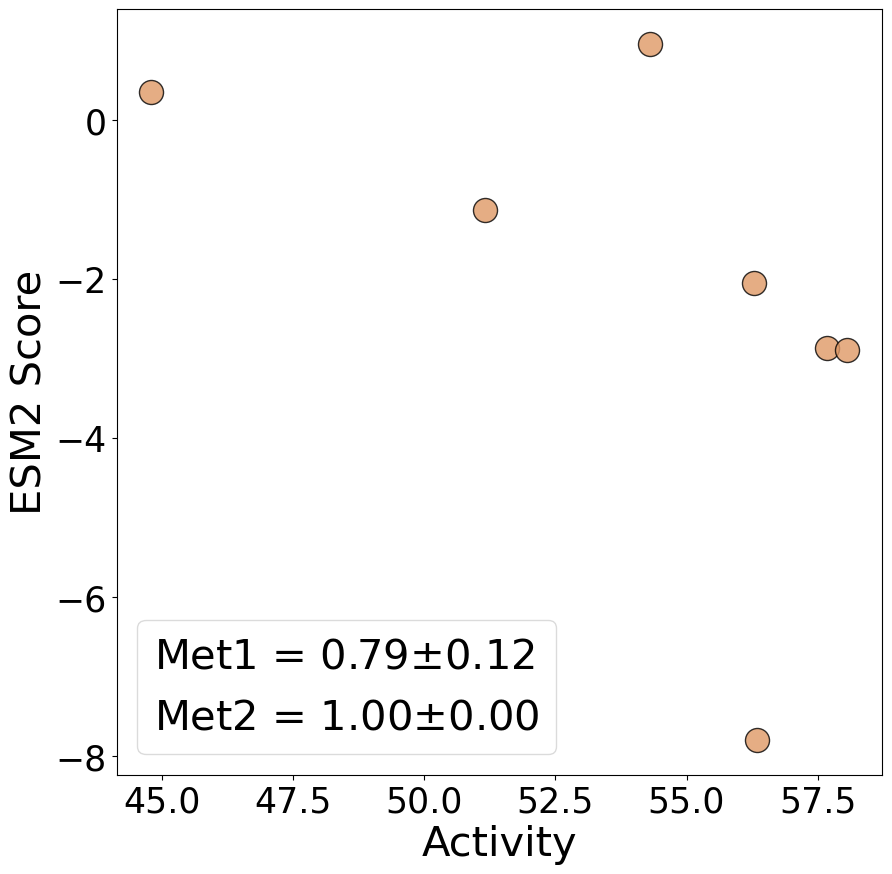

Worst Overall Model: ProtGPT2


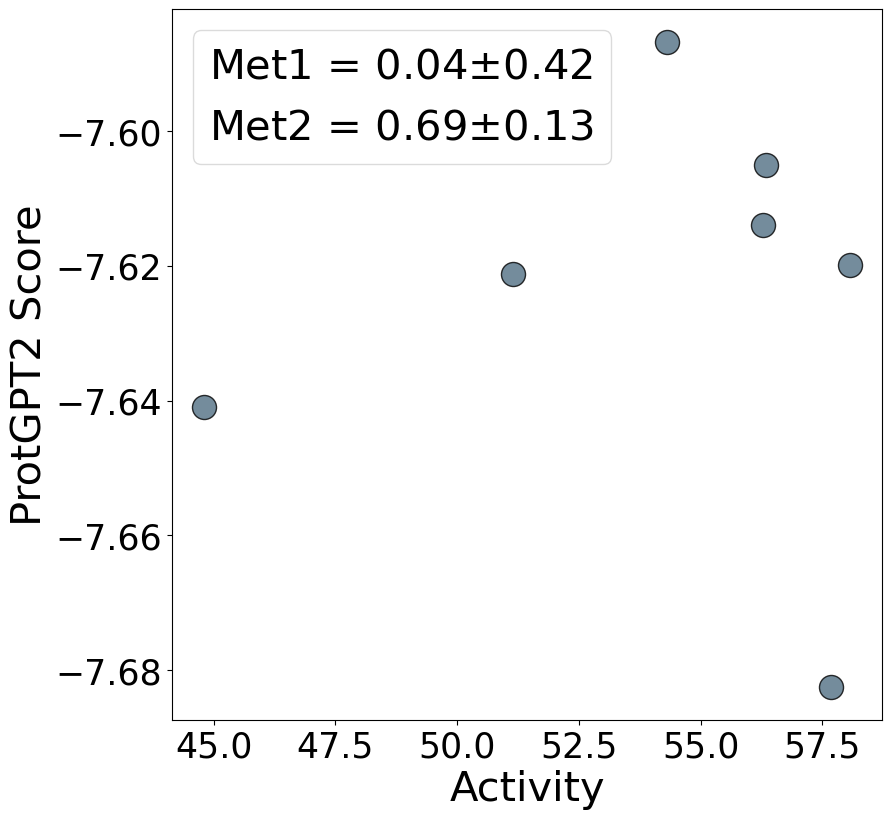

Sequence Model
Best Sequence Model: ESM2_150M


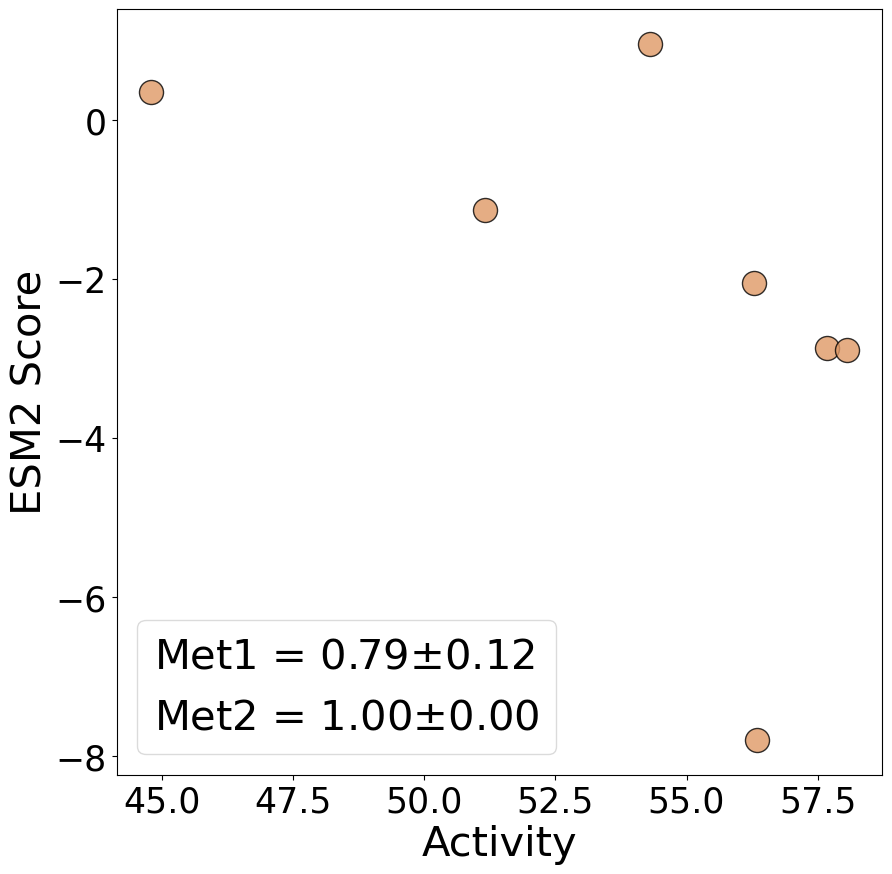

Worst Sequence Model: ProtGPT2


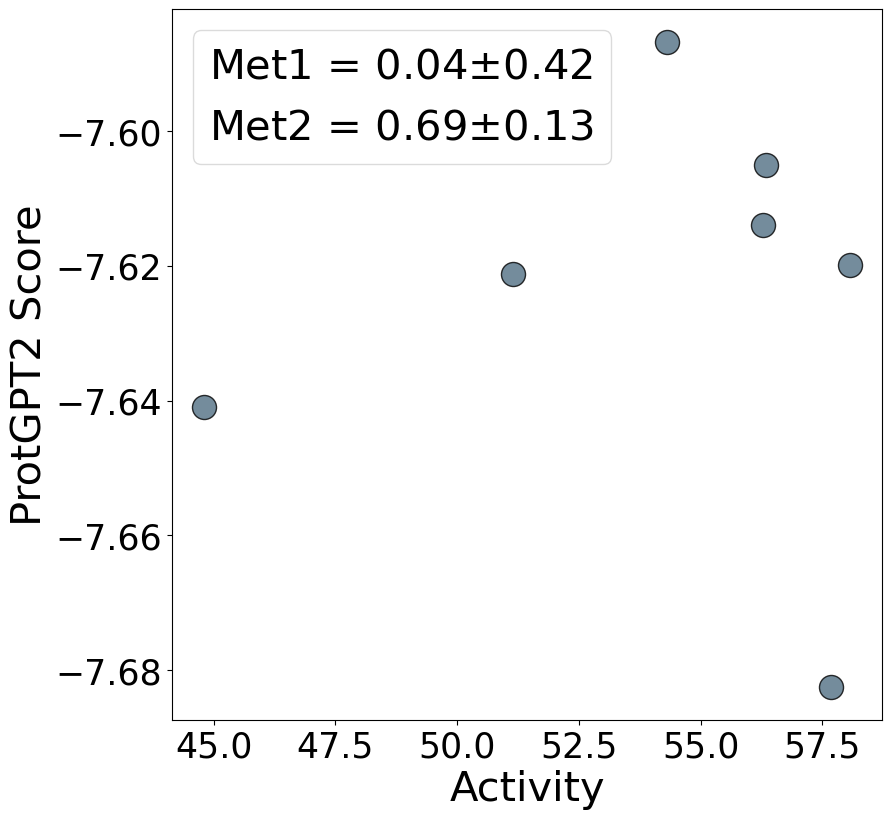

MSA Model
Best MSA Model: GEMME


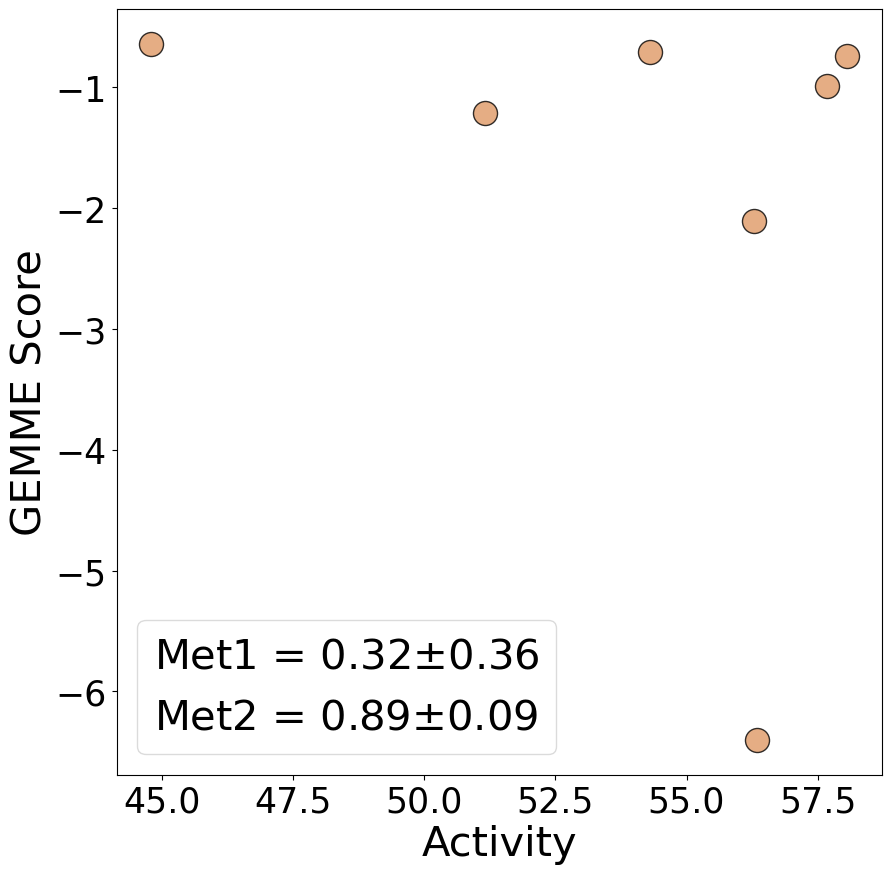

Worst MSA Model: EVE


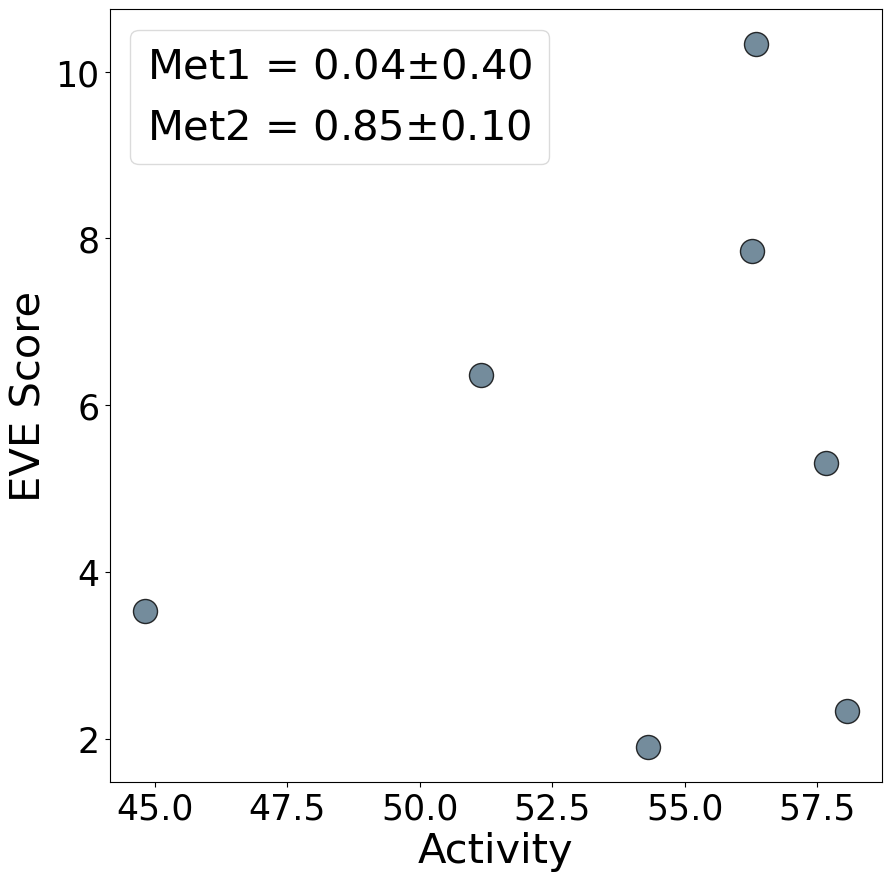

Structure Model
Best Structure Model: ProtSSN


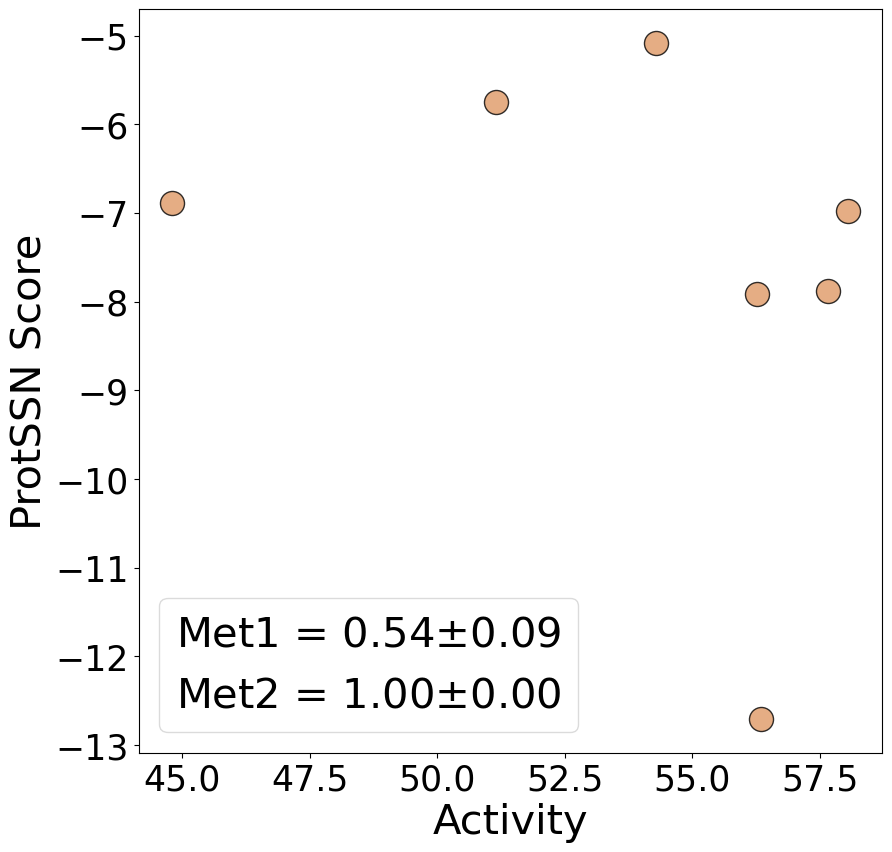

Worst Structure Model: MULAN_small


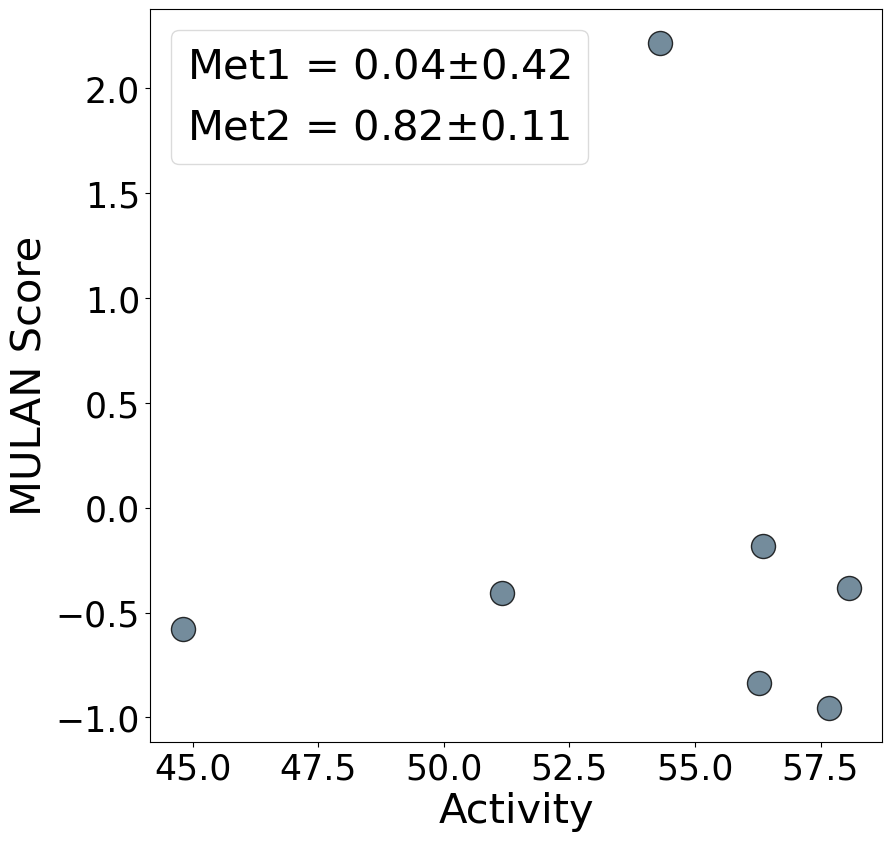

All features
Best Model using all features: RSALOR


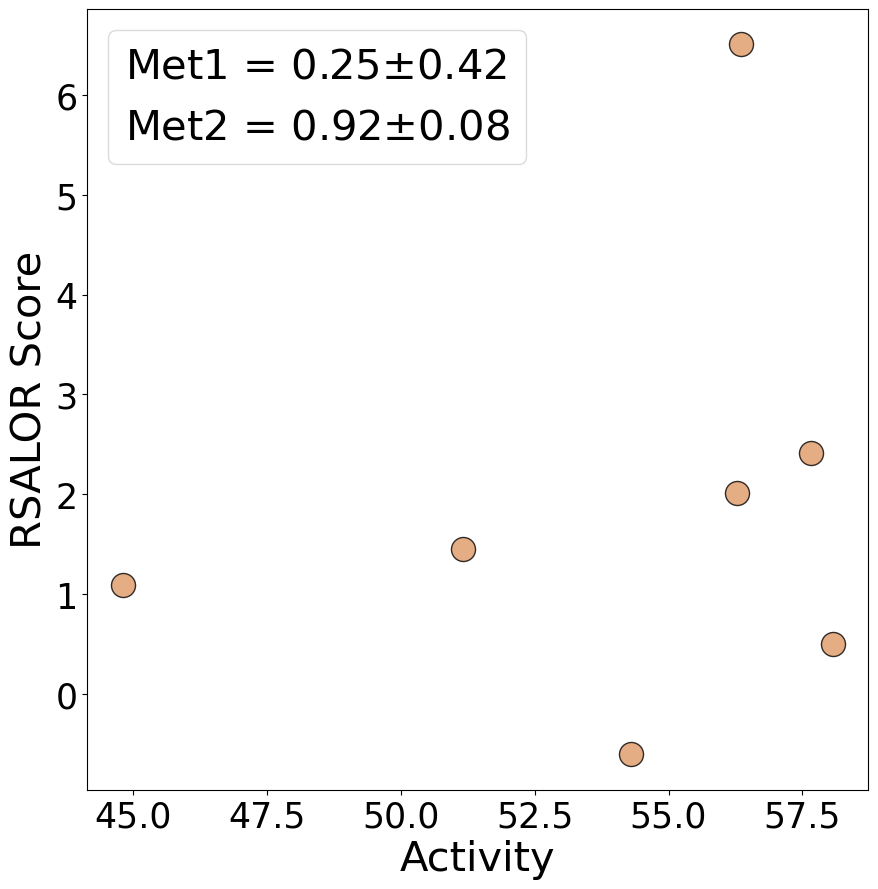

Worst Model using all features: VenusREM_512


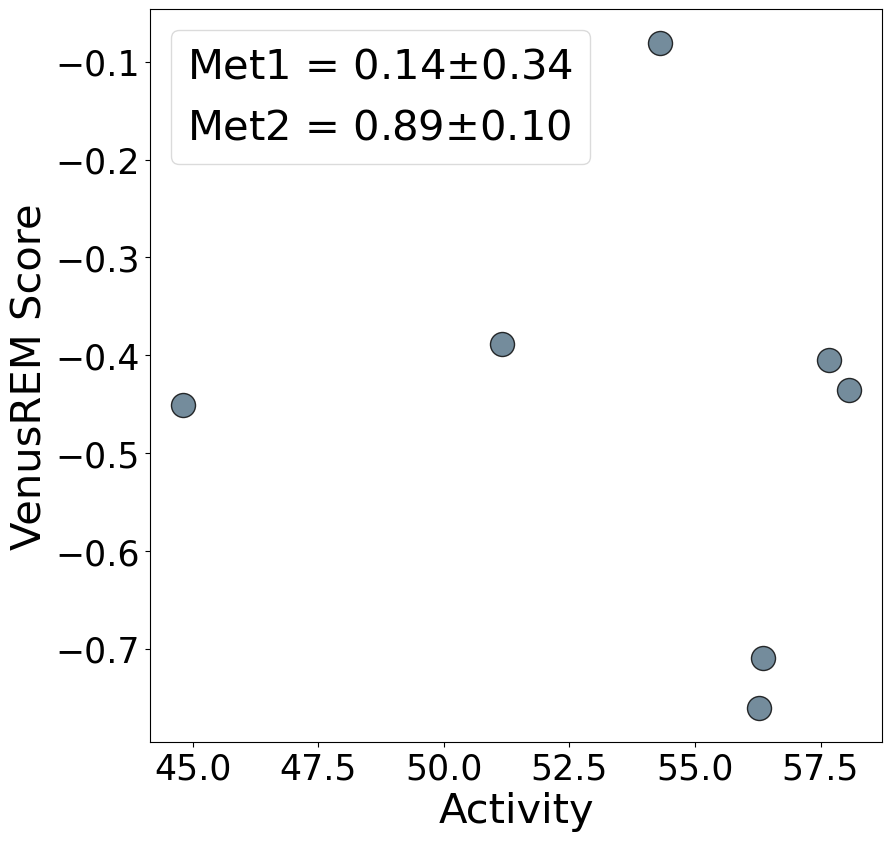

In [ ]:
# Plotting the performance of the best model
# Met1 = Absolute Spearman correlation
# Met2 = Average Precision
exp_property = 'Activity'
worst_color = '#516f84'
for name in lowN_name:
    print(f'Plotting results for {name}')

    print('Overall Model')
    best_ = prizm.best_models[name]['overall']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['overall']
    worst_score_name = worst_.split('_')[0]
    print('Best Overall Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Overall Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('Sequence Model')
    best_ = prizm.best_models[name]['sequence']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['sequence']
    worst_score_name = worst_.split('_')[0]
    print('Best Sequence Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Sequence Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('MSA Model')
    best_ = prizm.best_models[name]['MSA']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['MSA']
    worst_score_name = worst_.split('_')[0]
    print('Best MSA Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst MSA Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('Structure Model')
    best_ = prizm.best_models[name]['structure']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['structure']
    worst_score_name = worst_.split('_')[0]
    print('Best Structure Model:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Structure Model:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)

    print('All features')
    best_ = prizm.best_models[name]['all']
    best_score_name = best_.split('_')[0]
    worst_ = prizm.worst_models[name]['all']
    worst_score_name = worst_.split('_')[0]
    print('Best Model using all features:',best_)
    prizmplt.zs_vs_exp_scatter(prizm,name,best_,custom_zsname=best_score_name,custom_expname=exp_property, format='png',reg_plot=False)
    print('Worst Model using all features:',worst_)
    prizmplt.zs_vs_exp_scatter(prizm,name,worst_,custom_zsname=worst_score_name,custom_expname=exp_property, color=worst_color,format='png',reg_plot=False)





---

# Variant Ranking - In-silico Library

## Make in-silico library

---

In [10]:
# Change the values of the following variables as needed
dataset_name = 'TOGT1_1'
library_suffix = 'SMscan'
numb_mut = [1] # For both single and double mutants, use the format [1,2]
wt_seq = 'MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVFSKSIQRNKYLGIEIEIRLIKFPAVENDLPEECERLDQIPSDDKLSNFFKATAMMQEPLEQLIEECRPNCLVSDMFLPWTTDSAAKFNIPRIVFHGTSFFALCVENSVRLNKPYKNVSSDAETFVVPNLPHEIKLTRTQLSPFEQSGEETAMTRMIKTVRESDSKSYGVVFNSFYELETDYVEHYTKVLGRRAWAIGPLSMCNRDIEDKAERGKKSSIDKHECLKWLDSKKPSSVVYVCFGSVANFTASQLHELAMGIEASGQEFIWVVRTELDNEDWLPEGFEERTKEKGLIIRGWAPQVLILDHESVGAFVTHCGWNSTLEGVSGGVPMVTWPVFAEQFFNEKLVTEVLKTGAGVGSIQWKRSASEGVKREAIAKAIKRVMVSEEAEGFRNRAKAYKEMARKAVEEGGSSYTGLTTLLEDISTYTSTGH'

In [ ]:
# Generate the insilico library
insilico_library = prizm.insilico_library(dataset_name,numb_mut,wt_seq=wt_seq,custom_name=library_suffix)

---

## In silico library analysis

### Load dataset

---

In [11]:
# Change the values of the following variables as needed
dataset_name = 'TOGT1_1'
library_suffix = 'SMscan'
model_list_selection = ['ESM2','VenusREM','ESM1b'] # Best models from each category
library_name = dataset_name+'_'+library_suffix+'_insilico_library'

In [ ]:
prizm.set_threshold(library_name,wt_threshold[0])
prizm.load_scores(library_name,model_list_selection,wt=True)

---

### Sort and Rank library

---

In [ ]:
# Define the best models from each category and the overall best model
best_models = [prizm.best_models[lowN_name[0]][cat] for cat in ['sequence','all','structure']] # Best models from each category
best_overall = prizm.best_models[lowN_name[0]]['overall'] # Best overall model, used for final sorting

In [14]:
best_models

['ESM2_650M', 'VenusREM_4096', 'ProSST_1024']

In [ ]:
library_ranking = prizm.sorting_mutants(library_name,['VenusREM_4096'],best_overall,'../results/',wt=True,previous_metrics=prizm.metric_results[lowN_name[0]])

In [16]:
library_ranking

,mutant,mutated_sequence,WT,Mut,Pos,VenusREM,VenusREM_rank,VenusREM_bin
7608,G401I,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[G],[I],[401],1.620893,1.0,1
4531,W239I,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[W],[I],[239],1.428741,2.0,1
1363,N72S,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[N],[S],[72],1.295725,3.0,1
1349,N72A,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[N],[A],[72],1.252913,4.0,1
7618,G401V,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[G],[V],[401],1.233674,5.0,1
...,...,...,...,...,...,...,...,...
447,A24K,MGQLHFFFFPMMAHGHMIPTLDMKKLVASRGVKATIITTPLNESVF...,[A],[K],[24],-4.048508,9039.0,0
6872,G362P,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[G],[P],[362],-4.252641,9040.0,0
450,A24P,MGQLHFFFFPMMAHGHMIPTLDMPKLVASRGVKATIITTPLNESVF...,[A],[P],[24],-4.258015,9041.0,0
8038,I424R,MGQLHFFFFPMMAHGHMIPTLDMAKLVASRGVKATIITTPLNESVF...,[I],[R],[424],-4.279654,9042.0,0


### Single-Mutant Landscapes

---

In [15]:
# Change the values of the following variables as needed
landscape_rows = 4

In [ ]:
# Generating the SM landscapes for the three models
for model in ['ESM2_650M', 'VenusREM_4096']:
    prizm.sm_landscape(library_name,model,wt=True)
binary_landscape = (prizm.landscape['TOGT1_1_SMscan_insilico_library']['VenusREM_4096']>0).astype(int)

In [ ]:
prizmplt.heatmap(prizm, library_name, 'VenusREM_4096', landscape_rows, 'VenusREM Score',alpha=1,
               colors=['#34729F', 'white', '#F36906'], format='png',figsize=(60, 40))

NameError: name 'library_name' is not defined